### Main Training Notebook

In [3]:
# Install dependencies
# %pip install xgboost scikit-learn pandas numpy matplotlib seaborn

In [6]:
import subprocess
import sys
import os
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import LabelEncoder

In [7]:
OUTPUT_DIR = "./saved_models"

In [20]:
def convert_and_import(notebook_name, notebook_dir="."):
    nb_path = os.path.join(notebook_dir, f"{notebook_name}.ipynb")
    if not os.path.exists(nb_path):
        raise FileNotFoundError(f"Not found: {nb_path}")
    subprocess.run(
        [sys.executable, "-m", "nbconvert", "--to", "script",
         "--output", notebook_name, nb_path],
        capture_output=True, check=True
    )
    if notebook_dir not in sys.path:
        sys.path.insert(0, notebook_dir)
    if notebook_name in sys.modules:
        mod = importlib.reload(sys.modules[notebook_name])
    else:
        mod = importlib.import_module(notebook_name)
    print(f"Done with {notebook_name}")
    return mod

In [21]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))

ALL_NOTEBOOKS = [
    "model_isolation_forest",
    "model_xgboost",
    "model_random_forest",
    "model_decision_tree",
    "model_knn"
]

print("Importing notebooks...")
mods = {n: convert_and_import(n, NOTEBOOK_DIR) for n in ALL_NOTEBOOKS}

Importing notebooks...
Done with model_isolation_forest
Done with model_xgboost
Done with model_random_forest
Done with model_decision_tree
Done with model_knn


In [22]:
if_mod = mods["model_isolation_forest"]
xgb_mod = mods["model_xgboost"]
rf_mod = mods["model_random_forest"]
dt_mod  = mods["model_decision_tree"]
knn_mod  = mods["model_knn"]

In [23]:
# DATA LOADING

USE_DEMO_DATA = True

if USE_DEMO_DATA:
    X_raw, y_raw_int = make_classification(
        n_samples=12_000, n_features=84, n_informative=40,
        n_classes=8, n_clusters_per_class=1, random_state=42
    )
    ATTACK_CLASSES = ["Benign", "DDoS", "DoS", "Recon",
                      "Web-based", "BruteForce", "Spoofing", "Mirai"]
    y_raw = np.array([ATTACK_CLASSES[i] for i in y_raw_int])
    X_raw = pd.DataFrame(X_raw, columns=[f"feature_{i}" for i in range(84)])

else:
    # PROCESSED DATA SHOULD BE HERE
    pass

X_temp, X_test, y_temp, y_test = train_test_split(
    X_raw, y_raw, test_size=0.15, stratify=y_raw, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42
)

NORMAL_LABEL = "Benign"

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")
vals, counts = np.unique(y_train, return_counts=True)
for v, c in zip(vals, counts):
    print(f"  {v:15s}: {c:6,}")

Train : (8670, 84)  |  Val : (1530, 84)  |  Test : (1800, 84)
  Benign         :  1,080
  BruteForce     :  1,087
  DDoS           :  1,081
  DoS            :  1,081
  Mirai          :  1,082
  Recon          :  1,086
  Spoofing       :  1,086
  Web-based      :  1,087


Isolation Forest Anomaly Detector
Training on 1,080 benign samples (excluded 7,590 attack samples).
Isolation Forest fitted.
Threshold tuned: 0.08917  (val F1=0.9341)

Accuracy: 0.8771 | F1 (Attack): 0.9341 | ROC-AUC: 0.6107
              precision    recall  f1-score   support

      Benign       0.56      0.05      0.09       190
      Attack       0.88      0.99      0.93      1340

    accuracy                           0.88      1530
   macro avg       0.72      0.52      0.51      1530
weighted avg       0.84      0.88      0.83      1530

Saved > ./saved_models/isolation_forest.joblib


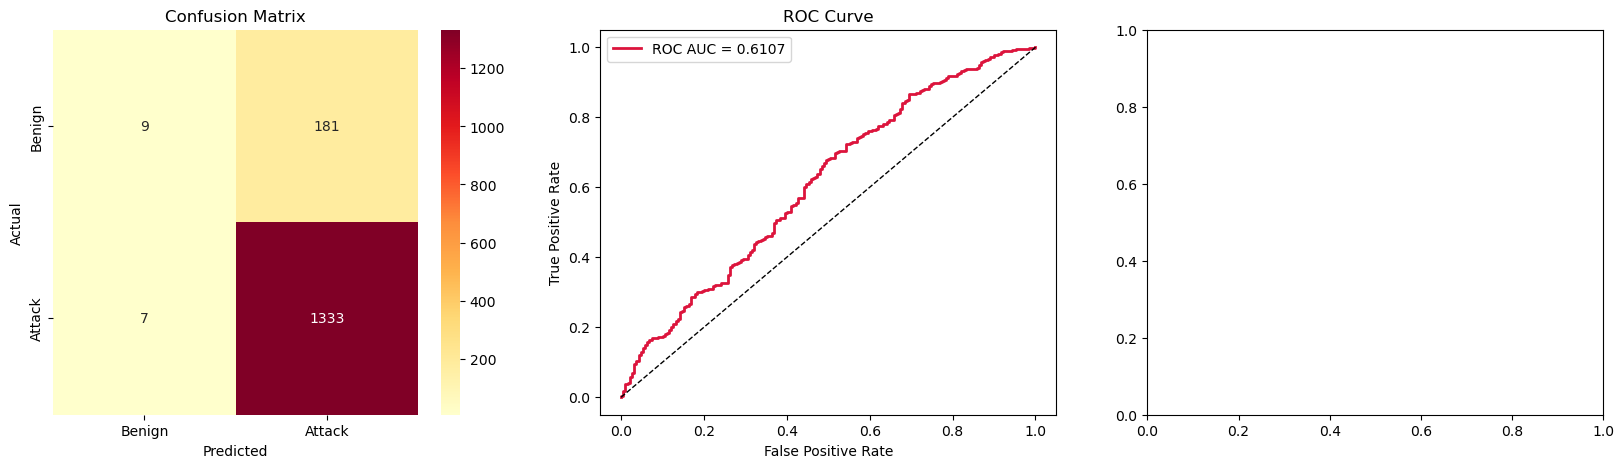

In [8]:
print("=" * 60)
print("Isolation Forest Anomaly Detector")
print("=" * 60)

model, threshold, metrics = if_mod.train(
    X_train, y_train,
    X_val, y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs= {
        "n_estimators":  200,
        "max_samples":   256,
        "contamination": "auto",
        "max_features":  1.0,
    },
    tune_threshold=True,
    save_path=os.path.join(OUTPUT_DIR, "isolation_forest.joblib")
)

In [24]:
attack_mask_tr = np.array(y_train) #!= NORMAL_LABEL
attack_labels  = np.array(y_train) #[attack_mask_tr]
shared_le = LabelEncoder()
shared_le.fit(attack_labels)

print(f"Attack classes ({len(shared_le.classes_)}): {shared_le.classes_}")

Attack classes (8): ['Benign' 'BruteForce' 'DDoS' 'DoS' 'Mirai' 'Recon' 'Spoofing' 'Web-based']


XGBoost
[0]	validation_0-mlogloss:1.98012
[50]	validation_0-mlogloss:0.71404
[100]	validation_0-mlogloss:0.47708
[150]	validation_0-mlogloss:0.39541
[200]	validation_0-mlogloss:0.35979
[250]	validation_0-mlogloss:0.34195
[299]	validation_0-mlogloss:0.33162

 Accuracy: 0.9163 | F1-macro: 0.9164
              precision    recall  f1-score   support

      Benign       0.93      0.94      0.94       190
  BruteForce       0.92      0.91      0.91       192
        DDoS       0.93      0.91      0.92       190
         DoS       0.91      0.90      0.91       191
       Mirai       0.94      0.92      0.93       191
       Recon       0.90      0.93      0.92       192
    Spoofing       0.92      0.89      0.90       192
   Web-based       0.89      0.93      0.91       192

    accuracy                           0.92      1530
   macro avg       0.92      0.92      0.92      1530
weighted avg       0.92      0.92      0.92      1530



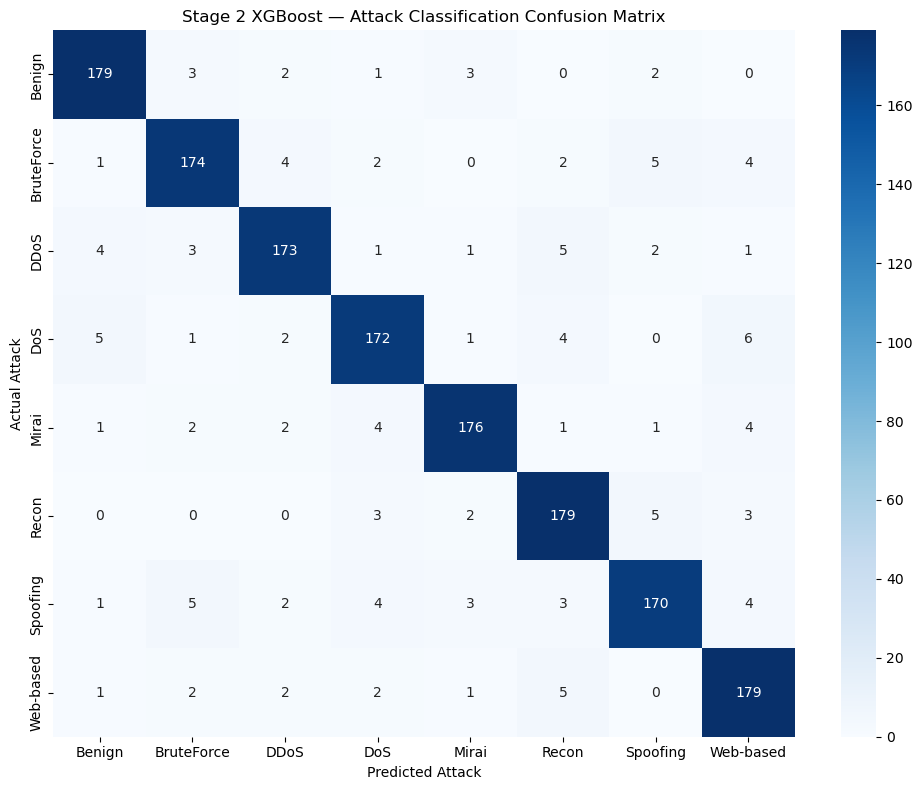

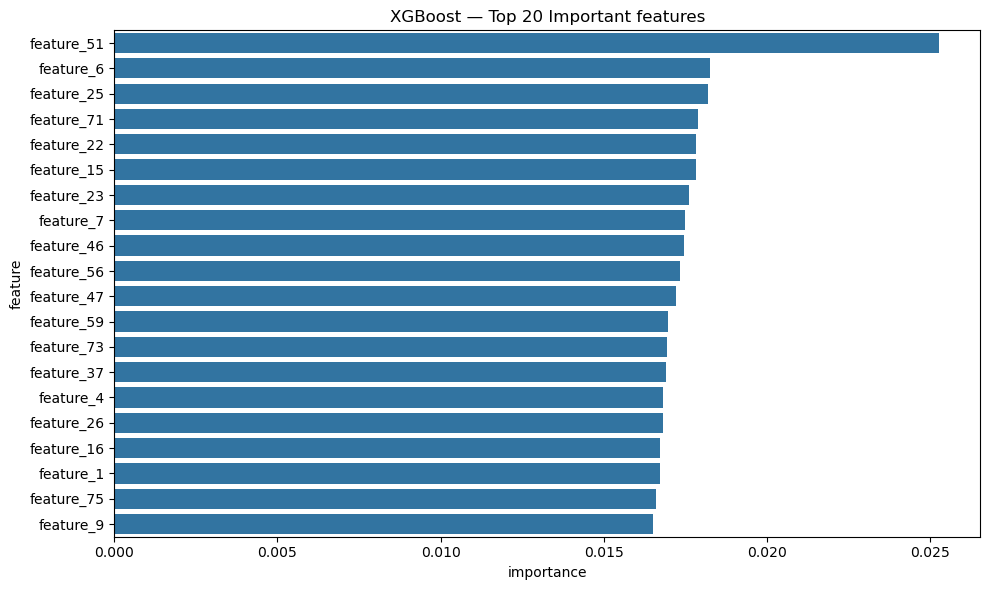

Saved > ./saved_models/xgboost.joblib


In [10]:
print("=" * 60)
print("XGBoost")
print("=" * 60)

model, metrics, label_eencoder = xgb_mod.train(
    X_train, y_train, X_val, y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs= {
        "n_estimators": 300, "max_depth": 8,
        "learning_rate": 0.1, "subsample": 0.8,
        "colsample_bytree": 0.8, "use_gpu": False,
    },
    label_encoder=shared_le,
    save_path=os.path.join(OUTPUT_DIR, "xgboost.joblib")
)

Random Forest Classifier
Training on 8,670 samples (1,080 benign, 7,590 attack).
Random Forest fitted.

Accuracy: 0.8948 | F1 (Attack): 0.9433 | ROC-AUC: 0.9806
              precision    recall  f1-score   support

      Benign       1.00      0.15      0.26       190
      Attack       0.89      1.00      0.94      1340

    accuracy                           0.89      1530
   macro avg       0.95      0.58      0.60      1530
weighted avg       0.91      0.89      0.86      1530



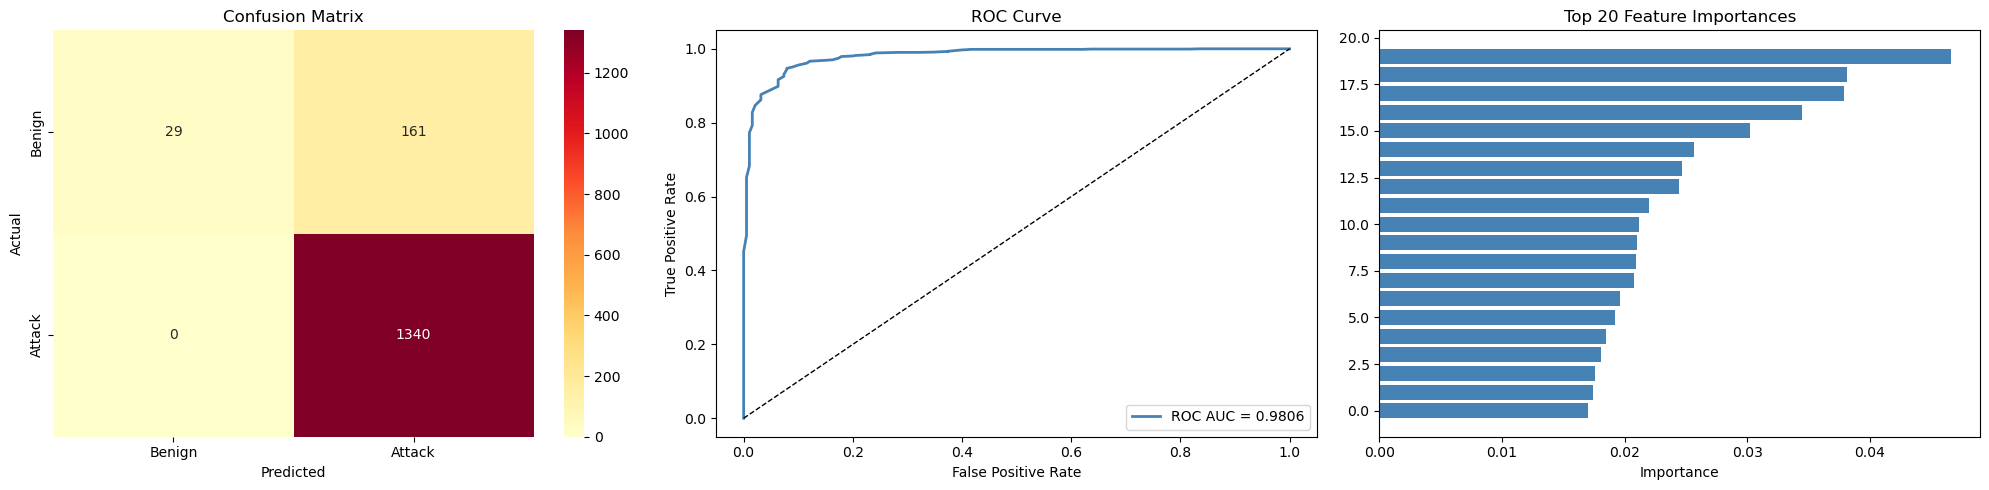

Saved > ./saved_models/random_forest.joblib


In [11]:
print("=" * 60)
print("Random Forest Classifier")
print("=" * 60)

rf_model, rf_metrics = rf_mod.train(
    X_train, y_train,
    X_val,   y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs={
        "n_estimators":  200,
        "max_depth":     None,
        "max_features":  "sqrt",
        "class_weight":  "balanced",
    },
    save_path=os.path.join(OUTPUT_DIR, "random_forest.joblib")
)

Decision Tree Classifier
Training on 8,670 samples (1,080 benign, 7,590 attack).
Decision Tree fitted.

Accuracy: 0.8745 | F1 (Attack): 0.9275 | ROC-AUC: 0.7391
              precision    recall  f1-score   support

      Benign       0.50      0.57      0.53       190
      Attack       0.94      0.92      0.93      1340

    accuracy                           0.87      1530
   macro avg       0.72      0.75      0.73      1530
weighted avg       0.88      0.87      0.88      1530



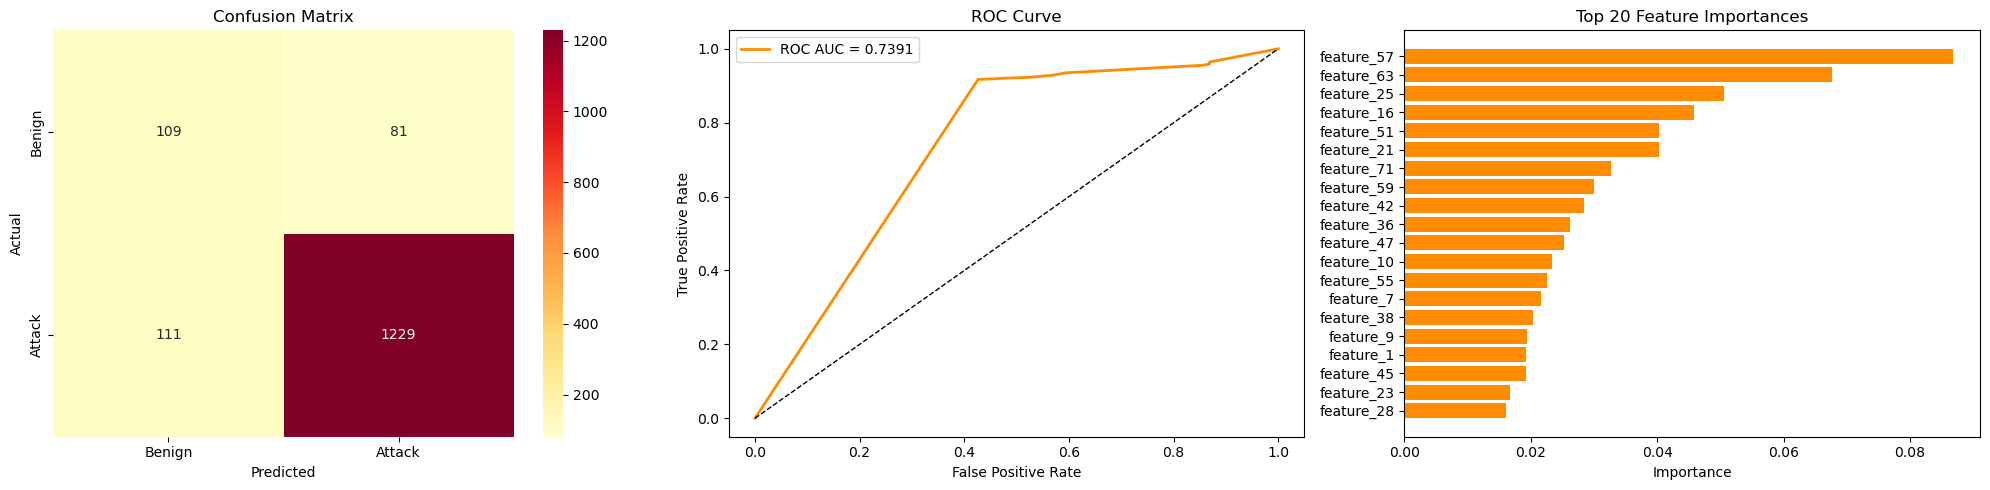

Saved > ./saved_models/decision_tree.joblib


In [17]:
print("=" * 60)
print("Decision Tree Classifier")
print("=" * 60)

dt_model, dt_metrics = dt_mod.train(
    X_train, y_train,
    X_val,   y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs={
        "max_depth":    20,
        "criterion":    "gini",
        "class_weight": "balanced",
    },
    save_path=os.path.join(OUTPUT_DIR, "decision_tree.joblib")
)

K-Nearest Neighbours Classifier
Training on 8,670 samples (1,080 benign, 7,590 attack).
Features scaled with StandardScaler.
KNN fitted.

Accuracy: 0.9405 | F1 (Attack): 0.9671 | ROC-AUC: 0.9500
              precision    recall  f1-score   support

      Benign       0.97      0.54      0.69       190
      Attack       0.94      1.00      0.97      1340

    accuracy                           0.94      1530
   macro avg       0.95      0.77      0.83      1530
weighted avg       0.94      0.94      0.93      1530



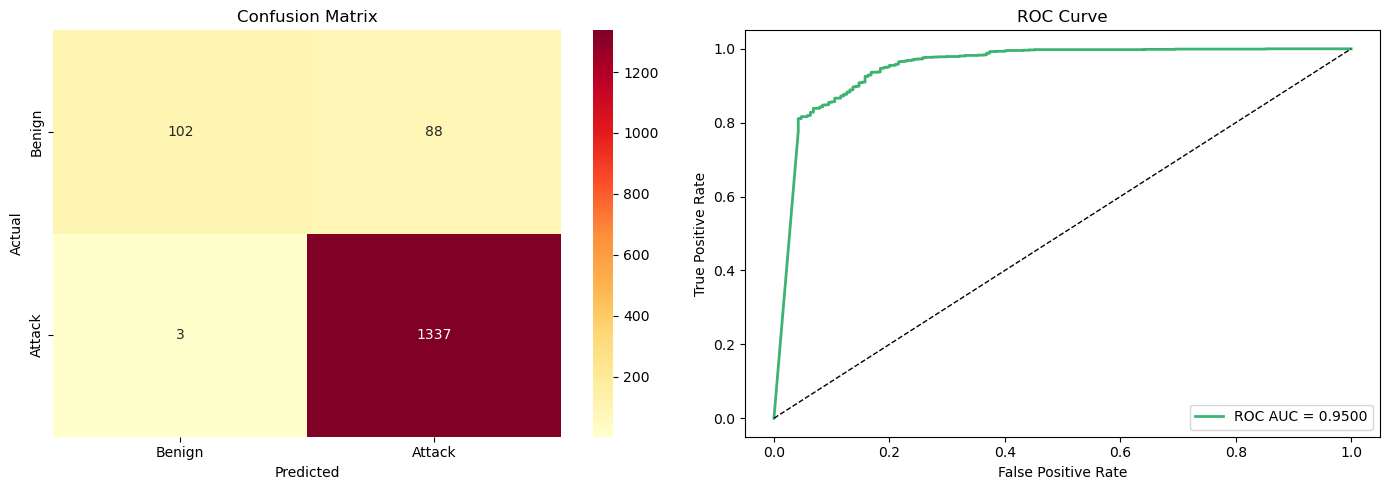

Saved > ./saved_models/knn.joblib


In [25]:
print("=" * 60)
print("K-Nearest Neighbours Classifier")
print("=" * 60)

knn_model, knn_scaler, knn_metrics = knn_mod.train(
    X_train, y_train,
    X_val,   y_val,
    normal_label=NORMAL_LABEL,
    model_kwargs={
        "n_neighbors": 5,
        "weights":     "distance",
        "metric":      "minkowski",
    },
    scale=True,
    save_path=os.path.join(OUTPUT_DIR, "knn.joblib")
)